In [138]:
%matplotlib inline
%reset -f

In [139]:
import numpy as np
import matplotlib.pyplot as plt

In [140]:
X_no_bias = np.array([[0,0],[1,0],[0,1],[1,1]], dtype=float)
T = np.array([[0],[1],[1],[0]], dtype=float)
X = np.hstack([X_no_bias, np.ones((4,1))])

In [141]:
W1 = np.array([[ 0.40 , -0.30 ],
               [-0.35,  0.45],
               [0.30 ,  0.30 ]], dtype=float)  # (3,2)
W2 = np.array([[ 0.5 ],
               [-0.6 ],
               [ 0.4 ]], dtype=float)

In [142]:
lr = 0.02
epochs = 100000

In [143]:
def sigmoid(z): return 1.0/(1.0+np.exp(-z))
def d_sigmoid(y): return y*(1.0-y)

In [144]:
mse_hist = []
for ep in range(int(epochs)):          # int로 고정
    sq_errs = []
    for i in range(4):
        xi = X[i:i+1]; ti = T[i:i+1]
        h  = sigmoid(xi @ W1)
        hb = np.hstack([h, np.ones((1,1))])
        o  = sigmoid(hb @ W2)
        sq_errs.append(0.5 * float((ti - o)**2))
        delta_o = (o - ti) * d_sigmoid(o)
        delta_h = (delta_o @ W2[:2].T) * d_sigmoid(h)
        W2 -= lr * (hb.T @ delta_o)
        W1 -= lr * (xi.T @ delta_h)
    mse_hist.append(np.mean(sq_errs))

C:\Users\user\AppData\Local\Temp\ipykernel_25196\2619928939.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sq_errs.append(0.5 * float((ti - o)**2))


In [145]:
print("len(mse_hist) =", len(mse_hist))

len(mse_hist) = 100000


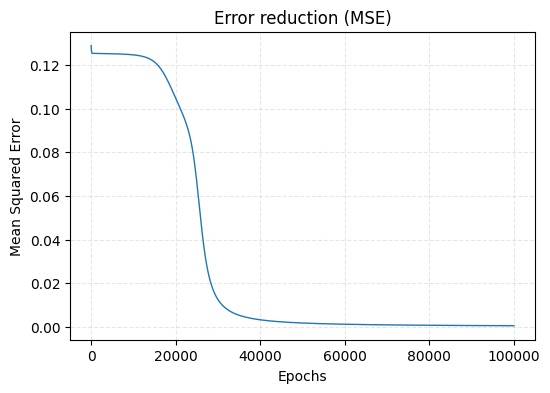

In [146]:
plt.figure(figsize=(6,4))
plt.plot(mse_hist, linewidth=1)
plt.title("Error reduction (MSE)")
plt.xlabel("Epochs"); plt.ylabel("Mean Squared Error")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()